<a href="https://colab.research.google.com/github/ADITI9981/Deep_Learning/blob/main/Bert_email_classification_handle_imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
!pip install -q tensorflow==2.18.0 tensorflow-text tensorflow-hub


In [42]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

In [43]:
import pandas as pd
df=pd.read_csv("spam.csv")
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [44]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [45]:
df['Category'].value_counts()

,count
Category,
ham,4825
spam,747


In [46]:
747/4825

0.15481865284974095

**15% spam emails, 85% ham emails: This indicates class imbalance**

In [47]:
df_spam = df[df['Category']=='spam']
df_spam.shape

(747, 2)

In [48]:
df_ham = df[df['Category']=='ham']
df_ham.shape

(4825, 2)

In [49]:
df_ham_downsampled = df_ham.sample(df_spam.shape[0])
df_ham_downsampled.shape

(747, 2)

In [50]:
df_balanced = pd.concat([df_spam, df_ham_downsampled])
df_balanced.shape

(1494, 2)

In [51]:
df_balanced['Category'].value_counts()

,count
Category,
spam,747
ham,747


In [52]:
df_balanced['spam']=df_balanced['Category'].apply(lambda x: 1 if x=='spam' else 0)
df_balanced.sample(5)

,Category,Message,spam
1845,ham,Da is good good player.why he is unsold.,0
29,ham,Ahhh. Work. I vaguely remember that! What does...,0
3874,ham,"Happy or sad , one thing about past is- ""Its n...",0
4329,spam,Congrats! 2 mobile 3G Videophones R yours. cal...,1
4198,spam,FREE for 1st week! No1 Nokia tone 4 ur mob eve...,1


In [53]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_balanced['Message'],df_balanced['spam'], stratify=df_balanced['spam'])

In [54]:
X_train.head(4)

,Message
1480,My trip was ok but quite tiring lor. Uni start...
2334,What happen to her tell the truth
1714,Hard LIVE 121 chat just 60p/min. Choose your g...
3554,Din i tell u jus now 420


**Now lets import BERT model and get embeding vectors for few sample statements**

In [55]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [56]:
def get_sentence_embeding(sentences):
    preprocessed_text = bert_preprocess(sentences)
    return bert_encoder(preprocessed_text)['pooled_output']

get_sentence_embeding([
    "500$ discount. hurry up",
    "Bhavin, are you up for a volleybal game tomorrow?"]
)

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.84351707, -0.51327264, -0.88845706, ..., -0.7474882 ,
        -0.75314736,  0.919645  ],
       [-0.8720834 , -0.50543964, -0.9444667 , ..., -0.85847497,
        -0.7174535 ,  0.8808297 ]], dtype=float32)>

**Get embeding vectors for few sample words. Compare them using cosine similarity**

In [57]:
e = get_sentence_embeding([
    "banana",
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
]
)

In [58]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity([e[0]],[e[1]])

array([[0.9911087]], dtype=float32)

In [59]:
cosine_similarity([e[0]],[e[3]])

array([[0.8470379]], dtype=float32)

**Build Model
There are two types of models you can build in tensorflow.

(1) Sequential (2) Functional

So far we have built sequential model. But below we will build functional model.**

In [60]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
sample = tf.constant(["Hello world!"])
bert_preprocess(sample)


{'input_type_ids': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
       dtype=int32)>,
 'input_mask': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 

In [82]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text  # For registering the BERT preprocessing ops

# Load the BERT preprocessing and encoder models
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3")

class BERTClassifier(tf.keras.Model):
    def __init__(self):
        super(BERTClassifier, self).__init__()
        self.bert_preprocess = bert_preprocess
        self.bert_encoder = bert_encoder
        self.dropout = tf.keras.layers.Dropout(0.1)
        self.dense = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')

    def call(self, inputs, training=False):
        preprocessed_text = self.bert_preprocess(inputs)
        encoder_output = self.bert_encoder(preprocessed_text)
        pooled_output = encoder_output['pooled_output']
        pooled_output = self.dropout(pooled_output, training=training)
        return self.dense(pooled_output)

# Instantiate and compile the model
model = BERTClassifier()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Test prediction with sample data
sample_texts = tf.constant([
    "Congratulations! You won a free iPhone.",
    "Hey, are we still on for lunch tomorrow?"
])

predictions = model(sample_texts)  # Output predictions
print(predictions)


Model: "bert_classifier_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

tf.Tensor(
[[0.46141136]
 [0.45713976]], shape=(2, 1), dtype=float32)


In [83]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [84]:

model.fit(X_train, y_train, epochs=10)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.5968 - precision: 1.0000 - recall: 1.0000
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 0.5444 - precision: 1.0000 - recall: 1.0000
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.5000 - loss: 0.5779 - precision: 0.5000 - recall: 1.0000
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 1.0000 - loss: 0.5746 - precision: 1.0000 - recall: 1.0000
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.5000 - loss: 0.7564 - precision: 0.5000 - recall: 1.0000
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5000 - loss: 0.6596 - precision: 0.5000 - recall: 1.0000
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.0000e+00 - loss: 0.8477 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5000 - loss: 0.6816 - precision: 0.5000 - recall: 1.0000
Epoch 9/10
1/1 ━━━━━━━━

In [85]:

len(X_train)

2

In [86]:
sample_texts = ["Sample text 1", "Sample text 2"]
sample_labels = [1, 0]

# Convert sample data to tensor
sample_texts = tf.convert_to_tensor(sample_texts, dtype=tf.string)
sample_labels = tf.convert_to_tensor(sample_labels, dtype=tf.int32)

# Make a prediction to check the model
predictions = model(sample_texts)
print(predictions)


tf.Tensor(
[[0.5096445 ]
 [0.48173657]], shape=(2, 1), dtype=float32)


In [87]:
model.evaluate(X_test, y_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - accuracy: 0.5161 - loss: 0.8335 - precision: 0.0000e+00 - recall: 0.0000e+00


[0.8581076264381409, 0.4946524202823639, 0.0, 0.0]

In [88]:
y_predicted = model.predict(X_test)
y_predicted = y_predicted.flatten()

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 303ms/step


In [89]:
import numpy as np

y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [90]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predicted)
cm

array([[185,   2],
       [187,   0]])

Text(50.722222222222214, 0.5, 'Truth')

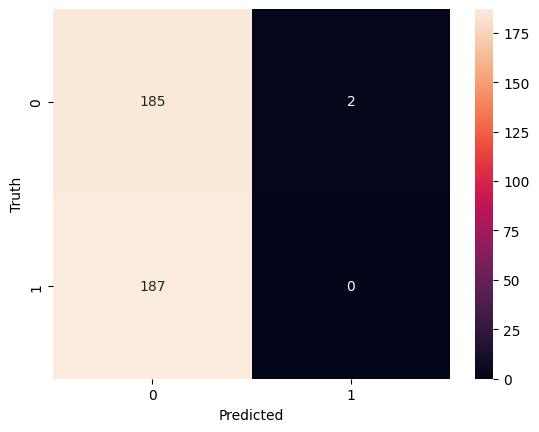

In [91]:
from matplotlib import pyplot as plt
import seaborn as sn
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [92]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.50      0.99      0.66       187
           1       0.00      0.00      0.00       187

    accuracy                           0.49       374
   macro avg       0.25      0.49      0.33       374
weighted avg       0.25      0.49      0.33       374

